In [94]:
import pandas as pd
import os
import sys
import json
from pathlib import Path
import numpy as np

# Notebook is in notebooks/, so repo root is parent
REPO_ROOT = Path.cwd().parent
SRC_PATH = REPO_ROOT / "src"

# Insert src at the front of sys.path so imports work
sys.path.insert(0, str(SRC_PATH))

In [95]:
import importlib
import preprocessing.ecg_preprocessing as ep

importlib.reload(ep)

<module 'preprocessing.ecg_preprocessing' from '/Users/brandonng/Documents/GitHub/ClinicalDigitalTwin/src/preprocessing/ecg_preprocessing.py'>

In [96]:
from preprocessing.ecg_preprocessing import load_ecg_data

# Get repo root relative to the current notebook
repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Load static preprocessing config
config_path = os.path.join(repo_root, "configs", "ecg_preprocessing_params.json")
with open(config_path, "r") as f:
    config = json.load(f)

# Set input and output directories
raw_dir = os.path.join(repo_root, config["paths"]["in_dir"])
processed_dir = os.path.join(repo_root, config["paths"]["processed_dir"])

# Pass directories to load function
ecg_record_list_df, machine_measurements_df, encounter_df = load_ecg_data(raw_dir, processed_dir, config)

In [97]:
machine_measurements_df.head(5)

,subject_id,study_id,cart_id,ecg_time,report_0,report_1,report_2,report_3,report_4,report_5,...,filtering,rr_interval,p_onset,p_end,qrs_onset,qrs_end,t_end,p_axis,qrs_axis,t_axis
0,10000032,40689238,6848296,2180-07-23 08:44:00,Sinus rhythm,Possible right atrial abnormality,NaN,Borderline ECG,NaN,NaN,...,60 Hz notch Baseline filter,659,40,128,170,258,518,81,77,79
1,10000032,44458630,6848296,2180-07-23 09:54:00,Sinus rhythm,Possible right atrial abnormality,NaN,Borderline ECG,NaN,NaN,...,60 Hz notch Baseline filter,722,40,124,162,246,504,77,75,70
2,10000032,49036311,6376932,2180-08-06 09:07:00,Sinus tachycardia,NaN,Normal ECG except for rate,NaN,NaN,NaN,...,60 Hz notch Baseline filter,600,40,130,162,244,474,79,72,77
3,10000117,45090959,6214760,2181-03-04 17:14:00,Sinus rhythm,NaN,Normal ECG,NaN,NaN,NaN,...,60 Hz notch Baseline filter,659,40,146,180,254,538,79,66,69
4,10000117,48446569,6632385,2183-09-18 13:52:00,Sinus rhythm,NaN,NaN,NaN,NaN,NaN,...,<not specified>,659,368,29999,504,590,868,84,80,77


# Machine Measurements

In [98]:
from preprocessing.ecg_preprocessing import preprocess_ecg_reports

cleaned_machine_measurements = preprocess_ecg_reports(machine_measurements_df)
cleaned_machine_measurements.head(5)

,subject_id,study_id,cart_id,ecg_time,bandwidth,filtering,rr_interval,p_onset,p_end,qrs_onset,qrs_end,t_end,p_axis,qrs_axis,t_axis,full_report
0,10000032,40689238,6848296,2180-07-23 08:44:00,0.005-150 Hz,60 Hz notch Baseline filter,659,40,128,170,258,518,81,77,79,"[sinus rhythm, possible right atrial abnormali..."
1,10000032,44458630,6848296,2180-07-23 09:54:00,0.005-150 Hz,60 Hz notch Baseline filter,722,40,124,162,246,504,77,75,70,"[sinus rhythm, possible right atrial abnormali..."
2,10000032,49036311,6376932,2180-08-06 09:07:00,0.005-150 Hz,60 Hz notch Baseline filter,600,40,130,162,244,474,79,72,77,"[sinus tachycardia, normal ecg except for rate]"
3,10000117,45090959,6214760,2181-03-04 17:14:00,0.005-150 Hz,60 Hz notch Baseline filter,659,40,146,180,254,538,79,66,69,"[sinus rhythm, normal ecg]"
4,10000117,48446569,6632385,2183-09-18 13:52:00,0.0005-150 Hz,<not specified>,659,368,29999,504,590,868,84,80,77,[sinus rhythm]


In [99]:
def count_total_elements(full_report):
    """Count total elements using list comprehension."""
    return sum(len(arr) for arr in full_report)

count_total_elements(cleaned_machine_measurements['full_report'])

2760027

In [100]:
from preprocessing.ecg_preprocessing import map_reports_to_labels

cleaned_machine_measurements["full_report"] = cleaned_machine_measurements["full_report"].apply(map_reports_to_labels)
cleaned_machine_measurements.head(5)

,subject_id,study_id,cart_id,ecg_time,bandwidth,filtering,rr_interval,p_onset,p_end,qrs_onset,qrs_end,t_end,p_axis,qrs_axis,t_axis,full_report
0,10000032,40689238,6848296,2180-07-23 08:44:00,0.005-150 Hz,60 Hz notch Baseline filter,659,40,128,170,258,518,81,77,79,"[borderline_ecg, right_atrial_enlargement, sin..."
1,10000032,44458630,6848296,2180-07-23 09:54:00,0.005-150 Hz,60 Hz notch Baseline filter,722,40,124,162,246,504,77,75,70,"[borderline_ecg, right_atrial_enlargement, sin..."
2,10000032,49036311,6376932,2180-08-06 09:07:00,0.005-150 Hz,60 Hz notch Baseline filter,600,40,130,162,244,474,79,72,77,"[normal_ecg, sinus_tachycardia]"
3,10000117,45090959,6214760,2181-03-04 17:14:00,0.005-150 Hz,60 Hz notch Baseline filter,659,40,146,180,254,538,79,66,69,"[normal_ecg, sinus_rhythm]"
4,10000117,48446569,6632385,2183-09-18 13:52:00,0.0005-150 Hz,<not specified>,659,368,29999,504,590,868,84,80,77,[sinus_rhythm]


In [101]:
count_total_elements(cleaned_machine_measurements['full_report'])

3313935

# Record List

In [102]:
ecg_record_list_df[ecg_record_list_df['subject_id']=='10000032'].head(5)

,subject_id,study_id,file_name,ecg_time,path
0,10000032,40689238,40689238,2180-07-23 08:44:00,files/p1000/p10000032/s40689238/40689238
1,10000032,44458630,44458630,2180-07-23 09:54:00,files/p1000/p10000032/s44458630/44458630
2,10000032,49036311,49036311,2180-08-06 09:07:00,files/p1000/p10000032/s49036311/49036311


In [103]:
encounter_df[encounter_df['subject_id'] == '10000032'].head(10)

,subject_id,hadm_id,ed_stay_id,ed_intime,ed_outtime,hosp_admittime,hosp_dischtime,race,gender,anchor_age,death_time,icu_stay_id,icu_intime,icu_outtime,icu_count,diagnosis,icd_codes
0,10000032,22595853.0,33258284.0,2180-05-06 19:17:00,2180-05-06 23:30:00,2180-05-06 22:23:00,2180-05-07 17:15:00,WHITE,F,52.0,2180-09-09 00:00:00,NaN,NaN,NaN,NaN,"['Portal hypertension', 'Other ascites', 'Cirr...","['5723', '78959', '5715', '07070', '496', '296..."
1,10000032,22841357.0,38112554.0,2180-06-26 15:54:00,2180-06-26 21:31:00,2180-06-26 18:27:00,2180-06-27 18:49:00,WHITE,F,52.0,2180-09-09 00:00:00,NaN,NaN,NaN,NaN,['Unspecified viral hepatitis C with hepatic c...,"['07071', '78959', '2875', '2761', '496', '571..."
2,10000032,25742920.0,35968195.0,2180-08-05 20:58:00,2180-08-06 01:44:00,2180-08-05 23:44:00,2180-08-07 17:50:00,WHITE,F,52.0,2180-09-09 00:00:00,NaN,NaN,NaN,NaN,['Chronic hepatitis C without mention of hepat...,"['07054', '78959', 'V462', '5715', '2767', '27..."
3,10000032,29079034.0,39399961.0,2180-07-23 05:54:00,2180-07-23 14:00:00,2180-07-23 12:35:00,2180-07-25 17:55:00,WHITE,F,52.0,2180-09-09 00:00:00,[39553978],['2180-07-23 14:00:00'],['2180-07-23 23:50:47'],1.0,"['Other iatrogenic hypotension', 'Chronic hepa...","['45829', '07044', '7994', '2761', '78959', '2..."


In [104]:
def match_ecg_to_encounters(ecg_record_list_df, encounter_df):
    """Match ECG records to hospital/ED encounters based on time windows."""
    # Create copies to avoid modifying original dataframes
    ecg_df = ecg_record_list_df.copy()
    enc_df = encounter_df.copy()
    
    # Ensure proper data types
    ecg_df["ecg_time"] = pd.to_datetime(ecg_df["ecg_time"])
    
    # Ensure time columns are datetime
    time_cols = ["hosp_admittime", "hosp_dischtime", "ed_intime", "ed_outtime"]
    enc_df[time_cols] = enc_df[time_cols].apply(pd.to_datetime)
    
    # Define columns to keep from encounter data
    encounter_time_cols = ['hadm_id', "hosp_admittime", "hosp_dischtime", 
                           "ed_intime", "ed_outtime", 'ed_stay_id', 
                           'icu_stay_id', 'icu_intime', 'icu_outtime', 'icd_codes']
    
    all_columns = list(ecg_df.columns) + encounter_time_cols
    
    # Merge ECG records with hospital/ED data
    merged = ecg_df.merge(enc_df, on="subject_id", how="left")[all_columns]
    
    # Check if ECG falls within hospital encounter window
    hosp_mask = (
        merged["hosp_admittime"].notna() &
        merged["hosp_dischtime"].notna() &
        merged["ecg_time"].between(merged["hosp_admittime"], merged["hosp_dischtime"])
    )
    
    # Check if ECG falls within ED encounter window
    ed_mask = (
        merged["ed_intime"].notna() &
        merged["ed_outtime"].notna() &
        merged["ecg_time"].between(merged["ed_intime"], merged["ed_outtime"])
    )
    
    # Keep only ECGs that fall within either hospital or ED encounter windows
    merged = merged[hosp_mask | ed_mask].copy()

    # Create binary indicators before filtering
    merged["in_hosp"] = hosp_mask[hosp_mask | ed_mask].astype(int)
    merged["in_ed"] = ed_mask[hosp_mask | ed_mask].astype(int)
    
    # Calculate window sizes for both encounter types
    hosp_win = merged["hosp_dischtime"] - merged["hosp_admittime"]
    ed_win = merged["ed_outtime"] - merged["ed_intime"]
    
    # Select the smaller window (prefer shorter, more specific encounters)
    merged["window_size"] = hosp_win.combine(
        ed_win,
        lambda h, e: h if pd.notna(h) and (pd.isna(e) or h <= e) else e
    )
    
    # For each study_id, keep only the row with the smallest window
    merged = (
        merged.sort_values(["study_id", "window_size"])
              .drop_duplicates("study_id", keep="first")
              .drop(["window_size", 'hosp_admittime', 'hosp_dischtime', 'ed_intime', 'ed_outtime'], axis=1)
    )
    
    return merged

distribution_test = match_ecg_to_encounters(ecg_record_list_df, encounter_df)
distribution_test.head(5)

,subject_id,study_id,file_name,ecg_time,path,hadm_id,ed_stay_id,icu_stay_id,icu_intime,icu_outtime,icd_codes,in_hosp,in_ed
4146579,16598616,40000035,40000035,2126-04-01 19:32:00,files/p1659/p16598616/s40000035/40000035,26101986.0,32731561.0,NaN,NaN,NaN,"['5409', '42789', '07054', '311', '30000', '79...",0,1
5286800,18370366,40000084,40000084,2179-08-30 11:58:00,files/p1837/p18370366/s40000084/40000084,NaN,37736561.0,NaN,NaN,NaN,"['78701', '5780']",0,1
1655942,12576058,40000115,40000115,2163-04-17 16:45:00,files/p1257/p12576058/s40000115/40000115,NaN,36567247.0,NaN,NaN,NaN,"['R001', 'Z950']",0,1
3004465,14691089,40000143,40000143,2175-07-21 01:01:00,files/p1469/p14691089/s40000143/40000143,23760732.0,38981935.0,NaN,NaN,NaN,"['S066X0A', 'Y048XXA', 'Y929', 'E119', 'K219',...",0,1
3850042,16089780,40000152,40000152,2137-01-29 19:08:00,files/p1608/p16089780/s40000152/40000152,NaN,31326149.0,NaN,NaN,NaN,"['78659', '78906', '25000', 'V5867', '4019']",0,1


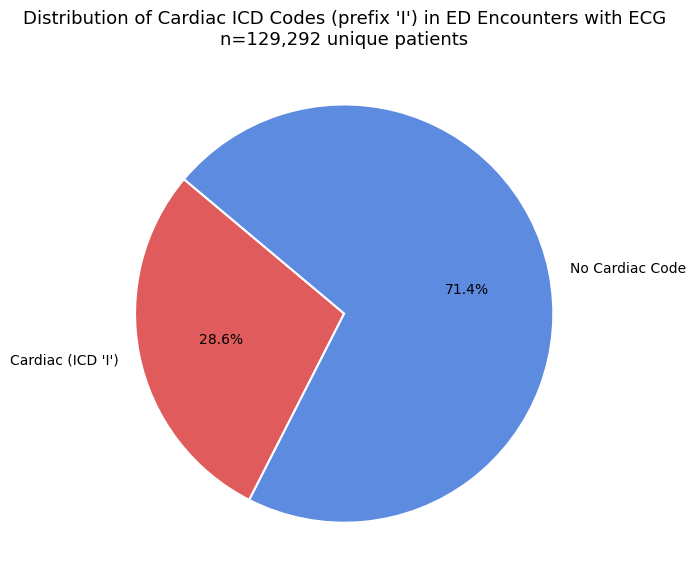

  Cardiac (ICD 'I'): 36,993 (28.6%)
  No Cardiac Code: 92,299 (71.4%)


In [105]:
import matplotlib.pyplot as plt
import ast

def plot_cardiac_icd_distribution(df, icd_col="icd_codes"):
    """Pie chart showing % of unique patients with at least one cardiac ICD code (starts with 'I')."""
    def parse_codes(val):
        if isinstance(val, list):
            return val
        if isinstance(val, str):
            try:
                return ast.literal_eval(val)
            except:
                return []
        return []

    # Deduplicate to unique patients
    df = df.drop_duplicates("ed_stay_id")

    has_cardiac = df[icd_col].apply(lambda x: any(str(c).startswith("I") for c in parse_codes(x)))

    counts = {
        "Cardiac (ICD 'I')": has_cardiac.sum(),
        "No Cardiac Code":   (~has_cardiac).sum()
    }

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.pie(
        counts.values(),
        labels=counts.keys(),
        autopct="%1.1f%%",
        startangle=140,
        colors=["#e05c5c", "#5c8be0"],
        wedgeprops={"edgecolor": "white", "linewidth": 1.5}
    )
    ax.set_title(
        f"Distribution of Cardiac ICD Codes (prefix 'I') in ED Encounters with ECG\nn={len(df):,} unique patients",
        fontsize=13
    )
    plt.tight_layout()
    plt.show()

    for label, count in counts.items():
        print(f"  {label}: {count:,} ({count/len(df)*100:.1f}%)")

plot_cardiac_icd_distribution(distribution_test[distribution_test['in_ed'] == 1])

In [106]:
from preprocessing.ecg_preprocessing import match_ecg_to_encounters

merged = match_ecg_to_encounters(ecg_record_list_df, encounter_df)
merged.head(5)


,subject_id,study_id,file_name,ecg_time,path,hadm_id,ed_stay_id,icu_stay_id,icu_intime,icu_outtime,in_hosp,in_ed
4146579,16598616,40000035,40000035,2126-04-01 19:32:00,files/p1659/p16598616/s40000035/40000035,26101986.0,32731561.0,NaN,NaN,NaN,0,1
5286800,18370366,40000084,40000084,2179-08-30 11:58:00,files/p1837/p18370366/s40000084/40000084,NaN,37736561.0,NaN,NaN,NaN,0,1
1655942,12576058,40000115,40000115,2163-04-17 16:45:00,files/p1257/p12576058/s40000115/40000115,NaN,36567247.0,NaN,NaN,NaN,0,1
3004465,14691089,40000143,40000143,2175-07-21 01:01:00,files/p1469/p14691089/s40000143/40000143,23760732.0,38981935.0,NaN,NaN,NaN,0,1
3850042,16089780,40000152,40000152,2137-01-29 19:08:00,files/p1608/p16089780/s40000152/40000152,NaN,31326149.0,NaN,NaN,NaN,0,1


In [107]:
merged[merged['subject_id'] == '10000032']

,subject_id,study_id,file_name,ecg_time,path,hadm_id,ed_stay_id,icu_stay_id,icu_intime,icu_outtime,in_hosp,in_ed
3,10000032,40689238,40689238,2180-07-23 08:44:00,files/p1000/p10000032/s40689238/40689238,29079034.0,39399961.0,[39553978],['2180-07-23 14:00:00'],['2180-07-23 23:50:47'],0,1
7,10000032,44458630,44458630,2180-07-23 09:54:00,files/p1000/p10000032/s44458630/44458630,29079034.0,39399961.0,[39553978],['2180-07-23 14:00:00'],['2180-07-23 23:50:47'],0,1
10,10000032,49036311,49036311,2180-08-06 09:07:00,files/p1000/p10000032/s49036311/49036311,25742920.0,35968195.0,NaN,NaN,NaN,1,0


In [108]:
from preprocessing.ecg_preprocessing import add_icu_indicator

final_ecg_record_list = add_icu_indicator(merged)
final_ecg_record_list.head(5)

,subject_id,study_id,file_name,ecg_time,path,hadm_id,ed_stay_id,icu_stay_id,in_hosp,in_ed,in_icu,icu_within_12hrs,icu_within_24hrs
4146579,16598616,40000035,40000035,2126-04-01 19:32:00,files/p1659/p16598616/s40000035/40000035,26101986.0,32731561.0,NaN,0,1,0,0,0
5286800,18370366,40000084,40000084,2179-08-30 11:58:00,files/p1837/p18370366/s40000084/40000084,NaN,37736561.0,NaN,0,1,0,0,0
1655942,12576058,40000115,40000115,2163-04-17 16:45:00,files/p1257/p12576058/s40000115/40000115,NaN,36567247.0,NaN,0,1,0,0,0
3004465,14691089,40000143,40000143,2175-07-21 01:01:00,files/p1469/p14691089/s40000143/40000143,23760732.0,38981935.0,NaN,0,1,0,0,0
3850042,16089780,40000152,40000152,2137-01-29 19:08:00,files/p1608/p16089780/s40000152/40000152,NaN,31326149.0,NaN,0,1,0,0,0


In [109]:
final_ecg_record_list[final_ecg_record_list['subject_id'] == '10000032']

,subject_id,study_id,file_name,ecg_time,path,hadm_id,ed_stay_id,icu_stay_id,in_hosp,in_ed,in_icu,icu_within_12hrs,icu_within_24hrs
3,10000032,40689238,40689238,2180-07-23 08:44:00,files/p1000/p10000032/s40689238/40689238,29079034.0,39399961.0,[39553978],0,1,0,1,1
7,10000032,44458630,44458630,2180-07-23 09:54:00,files/p1000/p10000032/s44458630/44458630,29079034.0,39399961.0,[39553978],0,1,0,1,1
10,10000032,49036311,49036311,2180-08-06 09:07:00,files/p1000/p10000032/s49036311/49036311,25742920.0,35968195.0,NaN,1,0,0,0,0


In [110]:
final_ecg_record_list[['icu_within_12hrs', 'icu_within_24hrs']].sum()


icu_within_12hrs    23400
icu_within_24hrs    27644
dtype: int64

In [111]:
# Test case 1: ECG during ICU stay (should be in_icu=1)
test_df1 = pd.DataFrame({
    'ecg_time': [pd.Timestamp('2180-07-23 18:00:00')],
    'in_hosp': [1],
    'icu_intime': [['2180-07-23 14:00:00']],
    'icu_outtime': [['2180-07-23 23:50:47']]
})

# Test case 2: ECG outside ICU stay (should be in_icu=0)
test_df2 = pd.DataFrame({
    'ecg_time': [pd.Timestamp('2180-07-24 10:00:00')],
    'in_hosp': [1],
    'icu_intime': [['2180-07-23 14:00:00']],
    'icu_outtime': [['2180-07-23 23:50:47']]
})

# Test case 3: Not in hospital (should be in_icu=0)
test_df3 = pd.DataFrame({
    'ecg_time': [pd.Timestamp('2180-07-23 18:00:00')],
    'in_hosp': [0],
    'icu_intime': [['2180-07-23 14:00:00']],
    'icu_outtime': [['2180-07-23 23:50:47']]
})

# Test case 4: Multiple ICU stays, ECG in second stay (should be in_icu=1)
test_df4 = pd.DataFrame({
    'ecg_time': [pd.Timestamp('2180-07-25 15:00:00')],
    'in_hosp': [1],
    'icu_intime': [['2180-07-23 14:00:00', '2180-07-25 10:00:00']],
    'icu_outtime': [['2180-07-23 23:50:47', '2180-07-25 20:00:00']]
})

# Test case 5: No ICU data (should be in_icu=0)
test_df5 = pd.DataFrame({
    'ecg_time': [pd.Timestamp('2180-07-23 18:00:00')],
    'in_hosp': [1],
    'icu_intime': [np.nan],
    'icu_outtime': [np.nan]
})

# Test case 6: ICU admission 6 hours after ECG (should be icu_within_12hrs=1, icu_within_24hrs=1)
test_df6 = pd.DataFrame({
    'ecg_time': [pd.Timestamp('2180-07-23 08:00:00')],
    'in_hosp': [1],
    'icu_intime': [['2180-07-23 14:00:00']],  # 6 hours later
    'icu_outtime': [['2180-07-23 23:50:47']]
})

# Test case 7: ICU admission 18 hours after ECG (should be icu_within_12hrs=0, icu_within_24hrs=1)
test_df7 = pd.DataFrame({
    'ecg_time': [pd.Timestamp('2180-07-23 08:00:00')],
    'in_hosp': [1],
    'icu_intime': [['2180-07-24 02:00:00']],  # 18 hours later
    'icu_outtime': [['2180-07-24 12:00:00']]
})

# Test case 8: ICU admission 30 hours after ECG (should be icu_within_12hrs=0, icu_within_24hrs=0)
test_df8 = pd.DataFrame({
    'ecg_time': [pd.Timestamp('2180-07-23 08:00:00')],
    'in_hosp': [1],
    'icu_intime': [['2180-07-24 14:00:00']],  # 30 hours later
    'icu_outtime': [['2180-07-24 20:00:00']]
})

# Test case 9: ICU before ECG (should be all 0)
test_df9 = pd.DataFrame({
    'ecg_time': [pd.Timestamp('2180-07-23 20:00:00')],
    'in_hosp': [1],
    'icu_intime': [['2180-07-23 14:00:00']],
    'icu_outtime': [['2180-07-23 18:00:00']]  # Ended before ECG
})

# Test case 10: ED case (in_hosp=0) with ICU 6 hours later (should be icu_within_12hrs=1, icu_within_24hrs=1)
test_df10 = pd.DataFrame({
    'ecg_time': [pd.Timestamp('2180-07-23 08:00:00')],
    'in_hosp': [0],  # ED case
    'icu_intime': [['2180-07-23 14:00:00']],  # 6 hours later
    'icu_outtime': [['2180-07-23 23:50:47']]
})

# Run tests
print("Test 1 (ECG during ICU):")
result1 = add_icu_indicator(test_df1)
print(result1[['in_icu', 'icu_within_12hrs', 'icu_within_24hrs']])
print(f"Expected: in_icu=1, icu_within_12hrs=0, icu_within_24hrs=0\n")

print("Test 2 (ECG outside ICU):")
result2 = add_icu_indicator(test_df2)
print(result2[['in_icu', 'icu_within_12hrs', 'icu_within_24hrs']])
print(f"Expected: in_icu=0, icu_within_12hrs=0, icu_within_24hrs=0\n")

print("Test 3 (Not in hospital):")
result3 = add_icu_indicator(test_df3)
print(result3[['in_icu', 'icu_within_12hrs', 'icu_within_24hrs']])
print(f"Expected: in_icu=0, icu_within_12hrs=0, icu_within_24hrs=0\n")

print("Test 4 (Multiple ICU stays, in second):")
result4 = add_icu_indicator(test_df4)
print(result4[['in_icu', 'icu_within_12hrs', 'icu_within_24hrs']])
print(f"Expected: in_icu=1, icu_within_12hrs=0, icu_within_24hrs=0\n")

print("Test 5 (No ICU data):")
result5 = add_icu_indicator(test_df5)
print(result5[['in_icu', 'icu_within_12hrs', 'icu_within_24hrs']])
print(f"Expected: in_icu=0, icu_within_12hrs=0, icu_within_24hrs=0\n")

Test 1 (ECG during ICU):
   in_icu  icu_within_12hrs  icu_within_24hrs
0       1                 0                 0
Expected: in_icu=1, icu_within_12hrs=0, icu_within_24hrs=0

Test 2 (ECG outside ICU):
   in_icu  icu_within_12hrs  icu_within_24hrs
0       0                 0                 0
Expected: in_icu=0, icu_within_12hrs=0, icu_within_24hrs=0

Test 3 (Not in hospital):
   in_icu  icu_within_12hrs  icu_within_24hrs
0       0                 0                 0
Expected: in_icu=0, icu_within_12hrs=0, icu_within_24hrs=0

Test 4 (Multiple ICU stays, in second):
   in_icu  icu_within_12hrs  icu_within_24hrs
0       1                 0                 0
Expected: in_icu=1, icu_within_12hrs=0, icu_within_24hrs=0

Test 5 (No ICU data):
   in_icu  icu_within_12hrs  icu_within_24hrs
0       0                 0                 0
Expected: in_icu=0, icu_within_12hrs=0, icu_within_24hrs=0



In [112]:
print("Test 6 (ICU 6 hrs after ECG):")
result6 = add_icu_indicator(test_df6)
print(result6[['in_icu', 'icu_within_12hrs', 'icu_within_24hrs']])
print(f"Expected: in_icu=0, icu_within_12hrs=1, icu_within_24hrs=1\n")

print("Test 7 (ICU 18 hrs after ECG):")
result7 = add_icu_indicator(test_df7)
print(result7[['in_icu', 'icu_within_12hrs', 'icu_within_24hrs']])
print(f"Expected: in_icu=0, icu_within_12hrs=0, icu_within_24hrs=1\n")

print("Test 8 (ICU 30 hrs after ECG):")
result8 = add_icu_indicator(test_df8)
print(result8[['in_icu', 'icu_within_12hrs', 'icu_within_24hrs']])
print(f"Expected: in_icu=0, icu_within_12hrs=0, icu_within_24hrs=0\n")

print("Test 9 (ICU before ECG):")
result9 = add_icu_indicator(test_df9)
print(result9[['in_icu', 'icu_within_12hrs', 'icu_within_24hrs']])
print(f"Expected: in_icu=0, icu_within_12hrs=0, icu_within_24hrs=0\n")

print("Test 10 (ED case with ICU 6 hrs later):")
result10 = add_icu_indicator(test_df10)
print(result10[['in_icu', 'icu_within_12hrs', 'icu_within_24hrs']])
print(f"Expected: in_icu=0, icu_within_12hrs=1, icu_within_24hrs=1\n")

Test 6 (ICU 6 hrs after ECG):
   in_icu  icu_within_12hrs  icu_within_24hrs
0       0                 1                 1
Expected: in_icu=0, icu_within_12hrs=1, icu_within_24hrs=1

Test 7 (ICU 18 hrs after ECG):
   in_icu  icu_within_12hrs  icu_within_24hrs
0       0                 0                 1
Expected: in_icu=0, icu_within_12hrs=0, icu_within_24hrs=1

Test 8 (ICU 30 hrs after ECG):
   in_icu  icu_within_12hrs  icu_within_24hrs
0       0                 0                 0
Expected: in_icu=0, icu_within_12hrs=0, icu_within_24hrs=0

Test 9 (ICU before ECG):
   in_icu  icu_within_12hrs  icu_within_24hrs
0       0                 0                 0
Expected: in_icu=0, icu_within_12hrs=0, icu_within_24hrs=0

Test 10 (ED case with ICU 6 hrs later):
   in_icu  icu_within_12hrs  icu_within_24hrs
0       0                 1                 1
Expected: in_icu=0, icu_within_12hrs=1, icu_within_24hrs=1



# ECG Dataset

In [113]:
print(final_ecg_record_list.shape)
final_ecg_record_list.head(5)

(411120, 13)


,subject_id,study_id,file_name,ecg_time,path,hadm_id,ed_stay_id,icu_stay_id,in_hosp,in_ed,in_icu,icu_within_12hrs,icu_within_24hrs
4146579,16598616,40000035,40000035,2126-04-01 19:32:00,files/p1659/p16598616/s40000035/40000035,26101986.0,32731561.0,NaN,0,1,0,0,0
5286800,18370366,40000084,40000084,2179-08-30 11:58:00,files/p1837/p18370366/s40000084/40000084,NaN,37736561.0,NaN,0,1,0,0,0
1655942,12576058,40000115,40000115,2163-04-17 16:45:00,files/p1257/p12576058/s40000115/40000115,NaN,36567247.0,NaN,0,1,0,0,0
3004465,14691089,40000143,40000143,2175-07-21 01:01:00,files/p1469/p14691089/s40000143/40000143,23760732.0,38981935.0,NaN,0,1,0,0,0
3850042,16089780,40000152,40000152,2137-01-29 19:08:00,files/p1608/p16089780/s40000152/40000152,NaN,31326149.0,NaN,0,1,0,0,0


In [114]:
print(cleaned_machine_measurements.shape)
cleaned_machine_measurements.head(5)

(800008, 16)


,subject_id,study_id,cart_id,ecg_time,bandwidth,filtering,rr_interval,p_onset,p_end,qrs_onset,qrs_end,t_end,p_axis,qrs_axis,t_axis,full_report
0,10000032,40689238,6848296,2180-07-23 08:44:00,0.005-150 Hz,60 Hz notch Baseline filter,659,40,128,170,258,518,81,77,79,"[borderline_ecg, right_atrial_enlargement, sin..."
1,10000032,44458630,6848296,2180-07-23 09:54:00,0.005-150 Hz,60 Hz notch Baseline filter,722,40,124,162,246,504,77,75,70,"[borderline_ecg, right_atrial_enlargement, sin..."
2,10000032,49036311,6376932,2180-08-06 09:07:00,0.005-150 Hz,60 Hz notch Baseline filter,600,40,130,162,244,474,79,72,77,"[normal_ecg, sinus_tachycardia]"
3,10000117,45090959,6214760,2181-03-04 17:14:00,0.005-150 Hz,60 Hz notch Baseline filter,659,40,146,180,254,538,79,66,69,"[normal_ecg, sinus_rhythm]"
4,10000117,48446569,6632385,2183-09-18 13:52:00,0.0005-150 Hz,<not specified>,659,368,29999,504,590,868,84,80,77,[sinus_rhythm]


In [115]:
ecg = final_ecg_record_list.merge(cleaned_machine_measurements, on=['subject_id', 'study_id', 'ecg_time'], how='inner')

print(ecg.shape)
ecg.head(5)

(403121, 26)


,subject_id,study_id,file_name,ecg_time,path,hadm_id,ed_stay_id,icu_stay_id,in_hosp,in_ed,...,rr_interval,p_onset,p_end,qrs_onset,qrs_end,t_end,p_axis,qrs_axis,t_axis,full_report
0,16598616,40000035,40000035,2126-04-01 19:32:00,files/p1659/p16598616/s40000035/40000035,26101986.0,32731561.0,NaN,0,1,...,800,40,162,194,286,576,48,14,33,"[abnormal_ecg, infarct_pattern, normal_ecg, si..."
1,18370366,40000084,40000084,2179-08-30 11:58:00,files/p1837/p18370366/s40000084/40000084,NaN,37736561.0,NaN,0,1,...,1176,40,140,202,280,602,59,56,45,"[normal_ecg, sinus_bradycardia, technical_error]"
2,12576058,40000115,40000115,2163-04-17 16:45:00,files/p1257/p12576058/s40000115/40000115,NaN,36567247.0,NaN,0,1,...,779,305,29999,503,627,971,0,83,50,[unspecified_ecg]
3,14691089,40000143,40000143,2175-07-21 01:01:00,files/p1469/p14691089/s40000143/40000143,23760732.0,38981935.0,NaN,0,1,...,690,348,29999,499,591,890,26,-49,59,"[infarct_pattern, sinus_rhythm]"
4,16089780,40000152,40000152,2137-01-29 19:08:00,files/p1608/p16089780/s40000152/40000152,NaN,31326149.0,NaN,0,1,...,645,40,124,176,268,536,51,29,63,"[borderline_ecg, sinus_rhythm, st_t_abnormality]"


In [116]:
print(f'Total Hours of ECG recordings: {ecg.shape[0] * 10 / 60 / 60}')

Total Hours of ECG recordings: 1119.7805555555556


In [117]:
print(f"Total Number of ECG recordings in ED: {sum(ecg['in_ed'])}")
print(f'Total Hours of ECG recordings in ED: {sum(ecg["in_ed"]) * 10 / 60 / 60}')

Total Number of ECG recordings in ED: 158284
Total Hours of ECG recordings in ED: 439.6777777777778


In [118]:
print(f"Total Number of ECG recordings in ED: {sum(ecg['in_hosp'])}")
print(f"Total Hours of ECG recordings in ED: {sum(ecg['in_hosp']) * 10 / 60 / 60}")

Total Number of ECG recordings in ED: 259465
Total Hours of ECG recordings in ED: 720.7361111111111


In [119]:
ecg.columns

Index(['subject_id', 'study_id', 'file_name', 'ecg_time', 'path', 'hadm_id',
       'ed_stay_id', 'icu_stay_id', 'in_hosp', 'in_ed', 'in_icu',
       'icu_within_12hrs', 'icu_within_24hrs', 'cart_id', 'bandwidth',
       'filtering', 'rr_interval', 'p_onset', 'p_end', 'qrs_onset', 'qrs_end',
       't_end', 'p_axis', 'qrs_axis', 't_axis', 'full_report'],
      dtype='object')

In [120]:
ecg.loc[ecg['full_report'].apply(lambda x: any('technical_error' in s for s in x)), 
        ['path', 'rr_interval', 'p_onset', 'p_end', 'qrs_onset', 'qrs_end',
         't_end', 'p_axis', 'qrs_axis', 't_axis']]


,path,rr_interval,p_onset,p_end,qrs_onset,qrs_end,t_end,p_axis,qrs_axis,t_axis
1,files/p1837/p18370366/s40000084/40000084,1176,40,140,202,280,602,59,56,45
250,files/p1598/p15980332/s40006670/40006670,555,40,152,174,290,544,59,58,4
345,files/p1403/p14032945/s40009157/40009157,923,40,154,236,322,640,57,-41,89
396,files/p1840/p18400980/s40010655/40010655,625,40,138,154,232,480,50,0,11
528,files/p1849/p18498541/s40013894/40013894,645,40,156,192,288,554,58,-4,112
...,...,...,...,...,...,...,...,...,...,...
402316,files/p1319/p13190947/s49979305/49979305,821,40,152,208,300,602,34,-8,3
402323,files/p1564/p15641327/s49979627/49979627,612,40,106,190,290,520,51,-51,76
402539,files/p1321/p13210648/s49985465/49985465,789,40,134,220,324,654,73,-45,72
402567,files/p1676/p16767048/s49986287/49986287,422,29999,29999,96,196,422,29999,-26,78
